# **Problema 1: Integración analítica de flujos**

Halle las trayectorias, las líneas de corriente las trazas de una partícula ubicada en $(x_0, y_0)$ a $t = 0$, para los siguientes campos de velocidades bidimensionales:

(i) Una corriente uniforme constante $U$ superpuesta a otra corriente uniforme ortogonal a la primera. La velocidad $U'$ de la segunda corriente está modulada en forma armónica en el tiempo con período $\tau$.

(ii) Un flujo con campo de velocidad dado por
$$ \mathbf{u}(x, y, t) =  \frac{\alpha x}{1+\beta t}\mathbf{\hat{x}} + c\mathbf{\hat{y}} $$


## (i) Corrientes uniformes superpuestas

El campo de velocidades es:
$$
\mathbf{u}(x,y,t) = U\,\hat{x} + U'(t)\,\hat{y}, \quad \text{con} \quad U'(t)=U_0\cos\left(\frac{2\pi}{\tau}t\right)
$$

### Trayectorias

Las trayectorias satisfacen:
$$
\frac{dx}{dt} = U, \quad \frac{dy}{dt} = U_0\cos\left(\frac{2\pi}{\tau}t\right)
$$

Integrando con condiciones iniciales $x(0)=x_0$, $y(0)=y_0$:

$$
x(t) = x_0 + Ut
$$

$$
y(t) = y_0 + \frac{U_0\tau}{2\pi}\sin\left(\frac{2\pi}{\tau}t\right)
$$

Por lo tanto:
$$
\begin{cases}
x(t) = x_0 + Ut \\
y(t) = y_0 + \dfrac{U_0\tau}{2\pi}\sin\left(\dfrac{2\pi}{\tau}t\right)
\end{cases}
$$

### Líneas de corriente

Se obtienen de:
$$
\frac{dy}{dx} = \frac{u_y}{u_x} = \frac{U_0\cos\left(\frac{2\pi}{\tau}t\right)}{U}
$$

Para un instante fijo $t=t_0$:

$$
\frac{dy}{dx} = \frac{U_0}{U}\cos\left(\frac{2\pi}{\tau}t_0\right)
$$

Integrando:

$$
y = \frac{U_0}{U}\cos\left(\frac{2\pi}{\tau}t_0\right)x + C
$$





## (ii) Campo de velocidad dependiente del tiempo

$$
\mathbf{u}(x,y,t) = \frac{\alpha x}{1+\beta t}\hat{x} + c\,\hat{y}
$$

### Trayectorias

$$
\frac{dx}{dt} = \frac{\alpha x}{1+\beta t}, \quad \frac{dy}{dt} = c
$$

Para $x(t)$:

$$
\frac{1}{x}dx = \frac{\alpha}{1+\beta t}dt
$$

$$
\ln x = \frac{\alpha}{\beta}\ln(1+\beta t) + C
$$

$$
x(t) = x_0(1+\beta t)^{\alpha/\beta}
$$

Para $y(t)$:

$$
y(t) = y_0 + ct
$$

Resultado:

$$
\begin{cases}
x(t) = x_0(1+\beta t)^{\alpha/\beta} \\
y(t) = y_0 + ct
\end{cases}
$$

### Líneas de corriente

$$
\frac{dy}{dx} =  \frac{u_y}{u_x} =\frac{c(1+\beta t)}{\alpha x}
$$

Para $t=t_0$:

$$
\frac{dy}{dx} = \frac{c(1+\beta t_0)}{\alpha x}
$$

$$
y = \frac{c(1+\beta t_0)}{\alpha}\ln x + C
$$


Con los resultados analiticos podemos empezar a escribir el codigo, primero empezamos definiendo los distintas funciones a utilizar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#========================== PARAMETROS FISICOS =======================
U_const = 1.0
U_amp = 1.5
tau = 2.0

alpha = 1.0
beta = 0.5
c = 1.0
#========================== CAMPOS DE VELOCIDADES =======================
def campo_1(X, t):
    """Campo de velocidades (i)"""
    u_x = U_const
    u_y = U_amp * np.cos(2 * np.pi * t / tau)
    return np.array([u_x, u_y])

def campo_2(X, t):
    """Campo de velocidades (ii)"""
    x = X[0]
    # Se evita división por cero si beta*t != -1
    u_x = (alpha * x) / (1 + beta * t)
    u_y = c
    return np.array([u_x, u_y])
    # Parámetros de integración

# ====================== SOLUCIONES ANALÍTICAS EXACTAS ======================
def exact_1(t, x0=1.0, y0=1.0):
    """Solución exacta Campo (i)"""
    x = x0 + U_const * t
    y = y0 + (U_amp * tau / (2 * np.pi)) * np.sin(2 * np.pi * t / tau)
    return np.array([x, y])

def exact_2(t, x0=1.0, y0=1.0):
    """Solución exacta Campo (ii)"""
    x = x0 * (1 + beta * t)**(alpha / beta)
    y = y0 + c * t
    return np.array([x, y])

# ====================== ESQUEMAS DE INTEGRACIÓN ======================
def esquema_euler(X, u, t, dt):
    """Euler explícito (el que ya tenías)"""
    return X + u(X, t) * dt

def esquema_rk4(X, u, t, dt):
    """Runge-Kutta orden 4"""
    k1 = u(X, t)
    k2 = u(X + 0.5*dt*k1, t + 0.5*dt)
    k3 = u(X + 0.5*dt*k2, t + 0.5*dt)
    k4 = u(X + dt*k3, t + dt)
    return X + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

# ====================== FUNCIÓN DE TRAYECTORIA (MODIFICADA) ======================
def trayectoria(X0, u, N, dt, esquema):
    """Calcula trayectoria usando el esquema que le pases (Euler o RK4)"""
    ts = np.arange(0, N+1) * dt
    Xs = np.zeros((N+1, 2))
    Xs[0] = X0
    for j in range(N):
        Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
    return ts, Xs



Notar que utilizamos dos esquemas de integracion numerica, esto con el objetivo de compararlos y ver cual tiene mejor desempeño en problemas de fluidos. (Por consistencia RK4 debe tener un error menor dado que esta en el quinto orden)
Por tanto usamos las soluciones exacatas anteriormente calculadas para esto, finalmente graficamos las trayectorias con todos los metodos y printeamos los resultados del error.

Campo (i)  → Error máx Euler: 1.50e-02   |   RK4: 1.61e-10
Campo (ii) → Error máx Euler: 1.49e-01   |   RK4: 1.40e-09


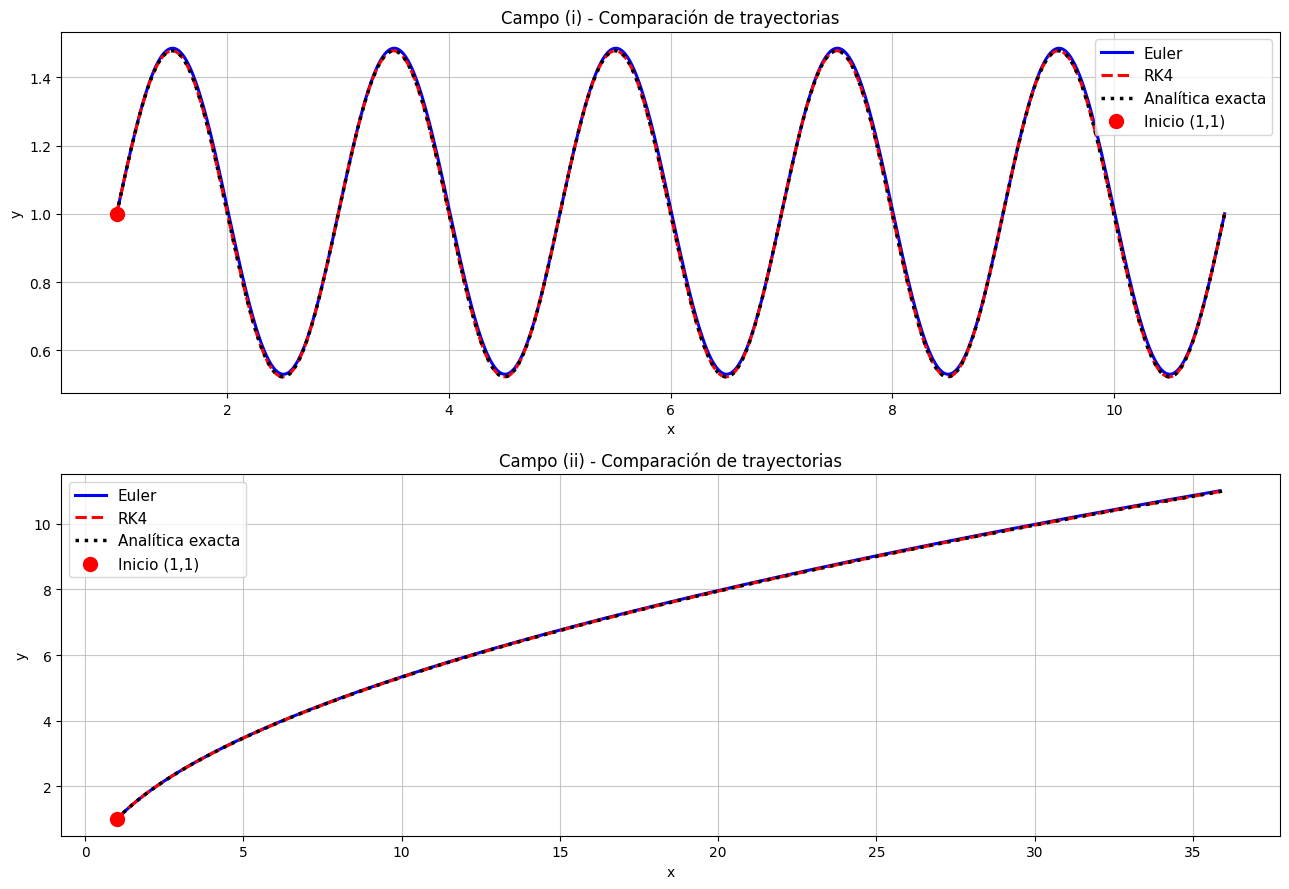

In [10]:
# ====================== PARÁMETROS ======================
dt = 0.01
N = 1000          # t_final = 10 segundos
X0 = np.array([1.0, 1.0])

# ====================== CÁLCULO DE TRAYECTORIAS ======================
# Campo (i)
ts, Xs_euler1 = trayectoria(X0, campo_1, N, dt, esquema_euler)
ts, Xs_rk41   = trayectoria(X0, campo_1, N, dt, esquema_rk4)
exact1 = np.array([exact_1(t) for t in ts])

# Campo (ii)
ts, Xs_euler2 = trayectoria(X0, campo_2, N, dt, esquema_euler)
ts, Xs_rk42   = trayectoria(X0, campo_2, N, dt, esquema_rk4)
exact2 = np.array([exact_2(t) for t in ts])

# ====================== ERRORES ======================
error_euler1 = np.linalg.norm(Xs_euler1 - exact1, axis=1).max()
error_rk41   = np.linalg.norm(Xs_rk41   - exact1, axis=1).max()
error_euler2 = np.linalg.norm(Xs_euler2 - exact2, axis=1).max()
error_rk42   = np.linalg.norm(Xs_rk42   - exact2, axis=1).max()

print(f"Campo (i)  → Error máx Euler: {error_euler1:.2e}   |   RK4: {error_rk41:.2e}")
print(f"Campo (ii) → Error máx Euler: {error_euler2:.2e}   |   RK4: {error_rk42:.2e}")

# ====================== GRÁFICOS DE LAS 4 TRAYECTORIAS ======================
fig, axs = plt.subplots(2, 1, figsize=(13, 9))

# Campo (i)
axs[0].plot(Xs_euler1[:,0], Xs_euler1[:,1], 'b-',  label='Euler', linewidth=2.2)
axs[0].plot(Xs_rk41[:,0],   Xs_rk41[:,1],   'r--', label='RK4',   linewidth=2.2)
axs[0].plot(exact1[:,0],    exact1[:,1],    'k:',  label='Analítica exacta', linewidth=2.5)
axs[0].scatter(X0[0], X0[1], color='red', s=100, zorder=5, label='Inicio (1,1)')
axs[0].set_title('Campo (i) - Comparación de trayectorias')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].grid(True, alpha=0.7)
axs[0].legend(fontsize=11)

# Campo (ii)
axs[1].plot(Xs_euler2[:,0], Xs_euler2[:,1], 'b-',  label='Euler', linewidth=2.2)
axs[1].plot(Xs_rk42[:,0],   Xs_rk42[:,1],   'r--', label='RK4',   linewidth=2.2)
axs[1].plot(exact2[:,0],    exact2[:,1],    'k:',  label='Analítica exacta', linewidth=2.5)
axs[1].scatter(X0[0], X0[1], color='red', s=100, zorder=5, label='Inicio (1,1)')
axs[1].set_title('Campo (ii) - Comparación de trayectorias')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].grid(True, alpha=0.7)
axs[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Tal como podemos ver todos los metodos convergen correctamente a la solucion analitica, siendo RK4 el esquema con mejor convergencia numerica tal como predijimos antes, sin embargo si aumentamos dt el error de los metodos deberia ser mas evidenciable, para ello:

Campo (i)  → Error máx Euler: 3.00e-01   |   RK4: 2.49e-05
Campo (ii) → Error máx Euler: 9.18e+02   |   RK4: 5.63e-02


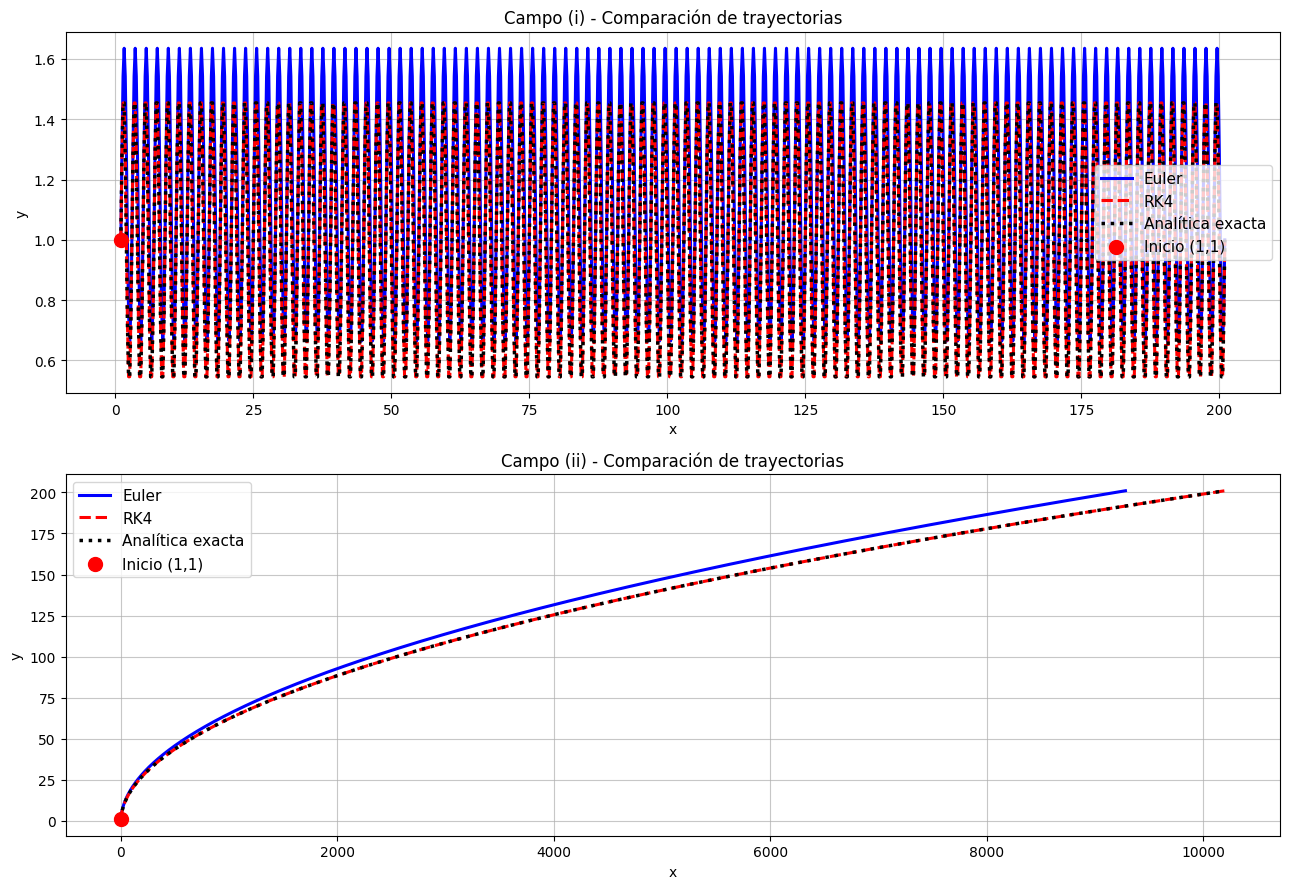

In [ ]:
# ====================== PARÁMETROS ======================
dt = 0.2
N = 1000          
X0 = np.array([1.0, 1.0])

# ====================== CÁLCULO DE TRAYECTORIAS ======================
# Campo (i)
ts, Xs_euler1 = trayectoria(X0, campo_1, N, dt, esquema_euler)
ts, Xs_rk41   = trayectoria(X0, campo_1, N, dt, esquema_rk4)
exact1 = np.array([exact_1(t) for t in ts])

# Campo (ii)
ts, Xs_euler2 = trayectoria(X0, campo_2, N, dt, esquema_euler)
ts, Xs_rk42   = trayectoria(X0, campo_2, N, dt, esquema_rk4)
exact2 = np.array([exact_2(t) for t in ts])

# ====================== ERRORES ======================
error_euler1 = np.linalg.norm(Xs_euler1 - exact1, axis=1).max()
error_rk41   = np.linalg.norm(Xs_rk41   - exact1, axis=1).max()
error_euler2 = np.linalg.norm(Xs_euler2 - exact2, axis=1).max()
error_rk42   = np.linalg.norm(Xs_rk42   - exact2, axis=1).max()

print(f"Campo (i)  → Error máx Euler: {error_euler1:.2e}   |   RK4: {error_rk41:.2e}")
print(f"Campo (ii) → Error máx Euler: {error_euler2:.2e}   |   RK4: {error_rk42:.2e}")

# ====================== GRÁFICOS DE LAS 4 TRAYECTORIAS ======================
fig, axs = plt.subplots(2, 1, figsize=(13, 9))

# Campo (i)
axs[0].plot(Xs_euler1[:,0], Xs_euler1[:,1], 'b-',  label='Euler', linewidth=2.2)
axs[0].plot(Xs_rk41[:,0],   Xs_rk41[:,1],   'r--', label='RK4',   linewidth=2.2)
axs[0].plot(exact1[:,0],    exact1[:,1],    'k:',  label='Analítica exacta', linewidth=2.5)
axs[0].scatter(X0[0], X0[1], color='red', s=100, zorder=5, label='Inicio (1,1)')
axs[0].set_title('Campo (i) - Comparación de trayectorias')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].grid(True, alpha=0.7)
axs[0].legend(fontsize=11)

# Campo (ii)
axs[1].plot(Xs_euler2[:,0], Xs_euler2[:,1], 'b-',  label='Euler', linewidth=2.2)
axs[1].plot(Xs_rk42[:,0],   Xs_rk42[:,1],   'r--', label='RK4',   linewidth=2.2)
axs[1].plot(exact2[:,0],    exact2[:,1],    'k:',  label='Analítica exacta', linewidth=2.5)
axs[1].scatter(X0[0], X0[1], color='red', s=100, zorder=5, label='Inicio (1,1)')
axs[1].set_title('Campo (ii) - Comparación de trayectorias')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].grid(True, alpha=0.7)
axs[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Tal como vimos el metodo de euler no converge correctamente para tiempos de integracion muy largos, siendo RK4 un metodo mucho mas confiable